# Imports

In [16]:
import os as _os
import os
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import optuna
import shap
import umap
import hdbscan

from joblib import dump, load
from sklearn.metrics import (
    classification_report,
    fbeta_score,
    f1_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

from datetime import datetime as _dt

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Configuration

In [ ]:
DB_PATH = "../data/sqlite/data.db"
TABLE   = "network_data"

# Samples per class (defined by the `label` column).
# - int  → same cap for every class
# - None → all available data (careful: may crash on large datasets)
SAMPLES_PER_CLASS: int | None = 615317
# Per-class overrides — take precedence over SAMPLES_PER_CLASS.
SAMPLES_PER_CLASS_OVERRIDE: dict = {}  # e.g. {"benign": 20_000}

# Binary sampling: (n_benign, n_attack) — overrides SAMPLES_PER_CLASS when set.
# Loads n_benign rows from BENIGN_LABEL and n_attack rows from all other
# classes combined, distributed evenly across attack classes.
# Set to None to fall back to SAMPLES_PER_CLASS.
BINARY_SAMPLING: tuple[int, int] | None = (615317, 615317)

BENIGN_LABEL: str = "benign"

USELESS_FEATURES = [
    "timestamp", "src_ip", "dst_ip", "src_port", "dst_port",
    # init_win features use -1 as sentinel for missing data;
    # this value does not appear in real traffic and biases predictions
    "init_fwd_win_byts", "init_bwd_win_byts",
    # bulk rate features are zero for virtually all real flows
    # (they require bulk detection heuristics that netflower does not apply)
    "fwd_byts_b_avg", "bwd_byts_b_avg",
    "fwd_pkts_b_avg", "bwd_pkts_b_avg",
    "fwd_blk_rate_avg", "bwd_blk_rate_avg",
]

RANDOM_SEED = 42

# --- Data cleaning ---
CORR_THRESHOLD     = 0.95   # drop features with pairwise Pearson correlation above this
VARIANCE_THRESHOLD = 1e-4   # drop features with variance below this

# --- Phase 1 — Binary Classification ---
FIXED_PARAMS = {
    "objective": "binary",
    "metric": "binary_logloss",
    "boosting_type": "gbdt",
    "random_state": RANDOM_SEED,
    "verbosity": -1,
    "force_row_wise": True,
    "n_jobs": 8,
}

# --- Phase 2 — Multiclass Classification ---
PHASE2_SAMPLES_PER_CLASS    = 615317
PHASE2_CONFIDENCE_THRESHOLD = 0.4   # max_proba below this → forwarded to Phase 3

# --- Phase 3 — Clustering (UMAP + HDBSCAN) ---
P3_UMAP_N_COMPONENTS        = 10
P3_UMAP_N_NEIGHBORS         = 30
P3_UMAP_MIN_DIST            = 0.0   # tight clusters → better HDBSCAN separation
P3_HDBSCAN_MIN_CLUSTER_SIZE = 100
P3_HDBSCAN_MIN_SAMPLES      = 50


In [3]:
_ts = _dt.now().strftime("%Y%m%d_%H%M%S")
_report_path = f"../docs/results/training_{_ts}.md"
_report_start = _dt.now()
_os.makedirs(_os.path.dirname(_report_path), exist_ok=True)

def _report_append(text: str) -> None:
    with open(_report_path, "a") as _f:
        _f.write(text)

_report_append(
    f"# Training Results — {_dt.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n"
    f"## Configuration\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"| Random seed | `{RANDOM_SEED}` |\n"
    f"| DB path | `{DB_PATH}` |\n"
    f"| Table | `{TABLE}` |\n"
    f"| Samples per class | `{SAMPLES_PER_CLASS}` |\n"
    f"| Binary sampling (benign, attack) | `{BINARY_SAMPLING}` |\n"
    f"| Benign label | `{BENIGN_LABEL}` |\n\n"
)
print(f"[report] Initialized → {_report_path}")

[report] Initialized → ../docs/results/training_20260518_130014.md


# Data - Phase 1

## Load Data

In [4]:
def load_dataset_from_db(
    db_path: str,
    table: str,
    samples_per_class: "int | None" = None,
    override: dict = {},
    binary_sampling: "tuple[int, int] | None" = None,
    benign_label: str = "benign",
) -> pd.DataFrame:
    """
    Load data from SQLite, sampling per class directly in the DB so that
    only the selected rows are pulled into memory.

    SQLite handles sampling with ORDER BY RANDOM() LIMIT n, avoiding the
    need to load the full dataset into pandas before filtering.

    DISTINCT is applied at the SQL level so duplicate rows from overlapping
    dataset captures are excluded before any rows are transferred to pandas.

    When binary_sampling=(n_benign, n_attack) is provided, samples n_benign
    rows from benign_label and distributes n_attack evenly across all attack
    classes (n_attack // num_attack_classes per class), ignoring
    samples_per_class and override.
    """
    conn = sqlite3.connect(db_path)

    if binary_sampling is not None:
        n_benign, n_attack = binary_sampling

        q_benign = f'SELECT * FROM "{table}" WHERE label = ? ORDER BY RANDOM() LIMIT ?'
        df_benign = pd.read_sql(q_benign, conn, params=(benign_label, n_benign))
        print(f"  {benign_label}: {len(df_benign):,} rows")

        attack_classes = pd.read_sql(
            f'SELECT DISTINCT label FROM "{table}" WHERE label != ? AND label IS NOT NULL',
            conn, params=(benign_label,)
        )["label"].tolist()

        n_per_class = n_attack // len(attack_classes)
        attack_frames = []
        for cls in sorted(attack_classes):
            q_cls = f'SELECT * FROM "{table}" WHERE label = ? ORDER BY RANDOM() LIMIT ?'
            df_cls = pd.read_sql(q_cls, conn, params=(cls, n_per_class))
            attack_frames.append(df_cls)
            print(f"  {cls}: {len(df_cls):,} rows")

        conn.close()
        result = pd.concat([df_benign] + attack_frames, ignore_index=True).sample(frac=1, random_state=RANDOM_SEED)
        print(f"\nTotal: {len(result):,} rows")
        return result

    classes = pd.read_sql(
        f'SELECT DISTINCT label FROM "{table}" WHERE label IS NOT NULL', conn
    )["label"].tolist()
    print(f"Classes: {sorted(classes)}")

    frames = []
    for cls in classes:
        n = override.get(cls, samples_per_class)

        if n is None:
            query = f'SELECT * FROM "{table}" WHERE label = ?'
            df_cls = pd.read_sql(query, conn, params=(cls,))
        else:
            query = f'SELECT * FROM "{table}" WHERE label = ? ORDER BY RANDOM() LIMIT ?'
            df_cls = pd.read_sql(query, conn, params=(cls, n))

        frames.append(df_cls)
        print(f"  {cls}: {len(df_cls):,} rows")

    conn.close()

    result = pd.concat(frames, ignore_index=True).sample(frac=1, random_state=RANDOM_SEED)
    print(f"\nTotal: {len(result):,} rows")
    return result


In [5]:
def load_dataset_from_csv(
    data_root: str,
    dataset: str,
    samples_per_class: "int | None" = None,
    override: dict = {},
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Alternative: load from CSV files directly.
    Only use for small datasets — large ones will exhaust RAM.
    """
    import glob
    dataset_path = os.path.join(data_root, dataset)
    csv_paths = sorted(glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True))
    if not csv_paths:
        raise FileNotFoundError(f"No CSVs found in: {dataset_path}")

    df = pd.concat((pd.read_csv(p) for p in csv_paths), ignore_index=True)

    if samples_per_class is None and not override:
        return df

    sampled = []
    for cls in df["label"].unique():
        n = override.get(cls, samples_per_class)
        cls_df = df[df["label"] == cls]
        sampled.append(cls_df.sample(min(n, len(cls_df)), random_state=random_state) if n else cls_df)

    return pd.concat(sampled, ignore_index=True).sample(frac=1, random_state=random_state)

In [6]:
df = load_dataset_from_db(
    DB_PATH,
    TABLE,
    samples_per_class=SAMPLES_PER_CLASS,
    override=SAMPLES_PER_CLASS_OVERRIDE,
    binary_sampling=BINARY_SAMPLING,
    benign_label=BENIGN_LABEL,
)
df.head()

  benign: 615,317 rows
  bruteforce: 16,397 rows
  ddos: 76,914 rows
  dos: 76,914 rows
  malware: 76,914 rows
  mitm: 76,914 rows
  recon: 76,914 rows
  spoofing: 76,914 rows
  web: 76,914 rows

Total: 1,170,112 rows


,src_ip,dst_ip,src_port,dst_port,protocol,timestamp,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,...,active_max,active_min,active_mean,active_std,idle_max,idle_min,idle_mean,idle_std,cwr_flag_count,label
245449,192.168.100.232,34.149.66.137,43632,443,6,1.778873e+09,0.034934,2.633552e+03,57.251135,28.625567,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,benign
77302,192.168.137.192,192.168.137.1,43643,53,17,1.665164e+09,0.042077,3.945142e+03,47.531833,23.765916,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,benign
1024176,192.168.137.42,205.174.165.69,56864,63686,17,1.668612e+09,53.906172,1.484060e+01,0.185508,0.185508,...,0.0,0.0,0.0,0.0,6.633092,5.365848,5.989575,0.323297,0,spoofing
882151,192.168.137.233,52.94.240.240,59826,443,6,1.666040e+09,0.000003,2.796203e+07,699050.666667,699050.666667,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,mitm
211416,157.249.81.141,192.168.137.41,443,37643,6,1.665184e+09,0.000000,0.000000e+00,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,benign


In [7]:
_class_counts = df["label"].value_counts().sort_index()
_counts_rows = "\n".join(f"| `{c}` | {n:,} |" for c, n in _class_counts.items())
_report_append(
    f"## Dataset — Phase 1\n\n"
    f"Raw shape after load: `{df.shape}`\n\n"
    f"| Class | Rows |\n"
    f"|-------|------|\n"
    f"{_counts_rows}\n"
    f"| **Total** | **{len(df):,}** |\n\n"
)
print("[report] Dataset section written.")

[report] Dataset section written.


## Data Cleaning

### Removing useless features

Some columns were discarded because they do not provide useful information
for training, or because they bias the model:
- **timestamp**: encodes the data collection time, not network behaviour.
  Including it would cause the model to memorize recording sessions rather
  than learn traffic patterns.
- **src\_ip / dst\_ip** (commented out): can be re-enabled if topological
  features are desired, but they add risk of dataset-specific overfitting.

In [8]:
removed_features: dict[str, list[str]] = {}

print("Before:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {list(df.columns)}")

actually_dropped = [c for c in USELESS_FEATURES if c in df.columns]
df = df.drop(columns=actually_dropped)
removed_features["useless_features"] = actually_dropped

print("\nAfter:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {list(df.columns)}")

Before:
  Shape: (1170112, 83)
  Columns: ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'timestamp', 'flow_duration', 'flow_byts_s', 'flow_pkts_s', 'fwd_pkts_s', 'bwd_pkts_s', 'tot_fwd_pkts', 'tot_bwd_pkts', 'totlen_fwd_pkts', 'totlen_bwd_pkts', 'fwd_pkt_len_max', 'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'pkt_len_max', 'pkt_len_min', 'pkt_len_mean', 'pkt_len_std', 'pkt_len_var', 'fwd_header_len', 'bwd_header_len', 'fwd_seg_size_min', 'fwd_act_data_pkts', 'flow_iat_mean', 'flow_iat_max', 'flow_iat_min', 'flow_iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min', 'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max', 'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fin_flag_cnt', 'syn_flag_cnt', 'rst_flag_cnt', 'psh_flag_cnt', 'ack_flag_cnt', 'urg_flag_cnt', 'ece_flag_cnt', 'down_up_ratio', 'pkt_size_avg', 'fwd_s

### Strip column-name whitespace

In [9]:
spaces_before = [c for c in df.columns if c != c.strip()]
print("Before - columns with spaces:", spaces_before)

df.columns = df.columns.str.strip()

spaces_after = [c for c in df.columns if c != c.strip()]
print("After  - columns with spaces:", spaces_after)
df.head()

Before - columns with spaces: []
After  - columns with spaces: []


,protocol,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,...,active_max,active_min,active_mean,active_std,idle_max,idle_min,idle_mean,idle_std,cwr_flag_count,label
245449,6,0.034934,2.633552e+03,57.251135,28.625567,28.625567,1,1,52,40,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,benign
77302,17,0.042077,3.945142e+03,47.531833,23.765916,23.765916,1,1,59,107,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,benign
1024176,17,53.906172,1.484060e+01,0.185508,0.185508,0.000000,10,0,800,0,...,0.0,0.0,0.0,0.0,6.633092,5.365848,5.989575,0.323297,0,spoofing
882151,6,0.000003,2.796203e+07,699050.666667,699050.666667,0.000000,2,0,80,0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,mitm
211416,6,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1,0,52,0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,benign


### Remove invalid values (NaN / Inf)

In [10]:
numeric_df = df.select_dtypes(include="number")

print("Before:")
print(f"  Shape: {df.shape}")
print(f"  NaN count:  {df.isna().sum().sum()}")
print(f"  Inf count:  {np.isinf(numeric_df).sum().sum()}")

df = df.replace([np.inf, -np.inf], np.nan).dropna()

numeric_df = df.select_dtypes(include="number")
print("\nAfter:")
print(f"  Shape: {df.shape}")
print(f"  NaN count:  {df.isna().sum().sum()}")
print(f"  Inf count:  {np.isinf(numeric_df).sum().sum()}")
df.head()

Before:
  Shape: (1170112, 70)
  NaN count:  0
  Inf count:  0

After:
  Shape: (1170112, 70)
  NaN count:  0
  Inf count:  0


,protocol,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,...,active_max,active_min,active_mean,active_std,idle_max,idle_min,idle_mean,idle_std,cwr_flag_count,label
245449,6,0.034934,2.633552e+03,57.251135,28.625567,28.625567,1,1,52,40,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,benign
77302,17,0.042077,3.945142e+03,47.531833,23.765916,23.765916,1,1,59,107,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,benign
1024176,17,53.906172,1.484060e+01,0.185508,0.185508,0.000000,10,0,800,0,...,0.0,0.0,0.0,0.0,6.633092,5.365848,5.989575,0.323297,0,spoofing
882151,6,0.000003,2.796203e+07,699050.666667,699050.666667,0.000000,2,0,80,0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,mitm
211416,6,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1,0,52,0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,benign


### Remove duplicate rows

In [11]:
print("Before:")
print(f"  Shape: {df.shape}")
print(f"  Duplicate rows: {df.duplicated().sum()}")

df = df.drop_duplicates()

print("\nAfter:")
print(f"  Shape: {df.shape}")
print(f"  Duplicate rows: {df.duplicated().sum()}")
df.head()

Before:
  Shape: (1170112, 70)
  Duplicate rows: 466097

After:
  Shape: (704015, 70)
  Duplicate rows: 0


,protocol,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,...,active_max,active_min,active_mean,active_std,idle_max,idle_min,idle_mean,idle_std,cwr_flag_count,label
245449,6,0.034934,2.633552e+03,57.251135,28.625567,28.625567,1,1,52,40,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,benign
77302,17,0.042077,3.945142e+03,47.531833,23.765916,23.765916,1,1,59,107,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,benign
1024176,17,53.906172,1.484060e+01,0.185508,0.185508,0.000000,10,0,800,0,...,0.0,0.0,0.0,0.0,6.633092,5.365848,5.989575,0.323297,0,spoofing
882151,6,0.000003,2.796203e+07,699050.666667,699050.666667,0.000000,2,0,80,0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,mitm
211416,6,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1,0,52,0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,benign


### Remove highly correlated features

Features with pairwise Pearson correlation > `CORR_THRESHOLD` add
redundant information and can slow training without improving accuracy.
We keep the first feature of each correlated pair (upper-triangle scan).

In [12]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
print("Before:")
print(f"  Shape: {df.shape}")

corr_matrix = df[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
print(f"  Dropped (corr > {CORR_THRESHOLD}): {to_drop}")

df = df.drop(columns=to_drop)
removed_features["high_correlation"] = to_drop

print("\nAfter:")
print(f"  Shape: {df.shape}")
df.head()

Before:
  Shape: (704015, 70)
  Dropped (corr > 0.95): ['fwd_pkts_s', 'fwd_seg_size_min', 'fwd_iat_tot', 'fwd_iat_max', 'psh_flag_cnt', 'ack_flag_cnt', 'pkt_size_avg', 'fwd_seg_size_avg', 'bwd_seg_size_avg', 'idle_max', 'idle_mean']

After:
  Shape: (704015, 59)


,protocol,flow_duration,flow_byts_s,flow_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,...,subflow_bwd_pkts,subflow_bwd_byts,active_max,active_min,active_mean,active_std,idle_min,idle_std,cwr_flag_count,label
245449,6,0.034934,2.633552e+03,57.251135,28.625567,1,1,52,40,52,...,1,40,0.0,0.0,0.0,0.0,0.000000,0.000000,0,benign
77302,17,0.042077,3.945142e+03,47.531833,23.765916,1,1,59,107,59,...,1,107,0.0,0.0,0.0,0.0,0.000000,0.000000,0,benign
1024176,17,53.906172,1.484060e+01,0.185508,0.000000,10,0,800,0,80,...,0,0,0.0,0.0,0.0,0.0,5.365848,0.323297,0,spoofing
882151,6,0.000003,2.796203e+07,699050.666667,0.000000,2,0,80,0,40,...,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0,mitm
211416,6,0.000000,0.000000e+00,0.000000,0.000000,1,0,52,0,52,...,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0,benign


### Remove near-zero variance features

Features whose variance is below `VARIANCE_THRESHOLD` carry almost no
discriminative signal and can cause numerical instability in some learners.

In [13]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
print("Before:")
print(f"  Shape: {df.shape}")

variances = df[numeric_cols].var()
low_var_cols = variances[variances < VARIANCE_THRESHOLD].index.tolist()
print(f"  Dropped (var < {VARIANCE_THRESHOLD}): {low_var_cols}")

df = df.drop(columns=low_var_cols)
removed_features["near_zero_variance"] = low_var_cols

print("\nAfter:")
print(f"  Shape: {df.shape}")
df.head()

Before:
  Shape: (704015, 59)
  Dropped (var < 0.0001): ['fwd_urg_flags', 'bwd_urg_flags', 'urg_flag_cnt']

After:
  Shape: (704015, 56)


,protocol,flow_duration,flow_byts_s,flow_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,...,subflow_bwd_pkts,subflow_bwd_byts,active_max,active_min,active_mean,active_std,idle_min,idle_std,cwr_flag_count,label
245449,6,0.034934,2.633552e+03,57.251135,28.625567,1,1,52,40,52,...,1,40,0.0,0.0,0.0,0.0,0.000000,0.000000,0,benign
77302,17,0.042077,3.945142e+03,47.531833,23.765916,1,1,59,107,59,...,1,107,0.0,0.0,0.0,0.0,0.000000,0.000000,0,benign
1024176,17,53.906172,1.484060e+01,0.185508,0.000000,10,0,800,0,80,...,0,0,0.0,0.0,0.0,0.0,5.365848,0.323297,0,spoofing
882151,6,0.000003,2.796203e+07,699050.666667,0.000000,2,0,80,0,40,...,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0,mitm
211416,6,0.000000,0.000000e+00,0.000000,0.000000,1,0,52,0,52,...,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0,benign


In [17]:
final_features = df.columns.tolist()
all_removed    = [col for cols in removed_features.values() for col in cols]

sep  = "=" * 60
sep2 = "-" * 60
lines = [
    sep,
    "FEATURE REPORT — DATA CLEANING SUMMARY",
    sep,
    "",
    f"Final features used ({len(final_features)}):",
]
for feat in sorted(final_features):
    lines.append(f"  + {feat}")

lines += ["", f"Excluded features ({len(all_removed)}):"]
for reason, cols in removed_features.items():
    if cols:
        lines += ["", f"  [{reason}]"]
        for col in sorted(cols):
            lines.append(f"    - {col}")

report = "\n".join(lines) + "\n"
print(report)

os.makedirs("../docs", exist_ok=True)
with open("../docs/features_report.txt", "w") as fh:
    fh.write(report)

print("Saved → ../docs/features_report.txt")

FEATURE REPORT — DATA CLEANING SUMMARY

Final features used (56):
  + active_max
  + active_mean
  + active_min
  + active_std
  + bwd_header_len
  + bwd_iat_max
  + bwd_iat_mean
  + bwd_iat_min
  + bwd_iat_std
  + bwd_iat_tot
  + bwd_pkt_len_max
  + bwd_pkt_len_mean
  + bwd_pkt_len_min
  + bwd_pkt_len_std
  + bwd_pkts_s
  + bwd_psh_flags
  + cwr_flag_count
  + down_up_ratio
  + ece_flag_cnt
  + fin_flag_cnt
  + flow_byts_s
  + flow_duration
  + flow_iat_max
  + flow_iat_mean
  + flow_iat_min
  + flow_iat_std
  + flow_pkts_s
  + fwd_act_data_pkts
  + fwd_header_len
  + fwd_iat_mean
  + fwd_iat_min
  + fwd_iat_std
  + fwd_pkt_len_max
  + fwd_pkt_len_mean
  + fwd_pkt_len_min
  + fwd_pkt_len_std
  + fwd_psh_flags
  + idle_min
  + idle_std
  + label
  + pkt_len_max
  + pkt_len_mean
  + pkt_len_min
  + pkt_len_std
  + pkt_len_var
  + protocol
  + rst_flag_cnt
  + subflow_bwd_byts
  + subflow_bwd_pkts
  + subflow_fwd_byts
  + subflow_fwd_pkts
  + syn_flag_cnt
  + tot_bwd_pkts
  + tot_fwd_pkt

In [18]:
def _py_list(items, indent=4):
    pad = " " * indent
    inner = "\n".join(f'{pad}"{item}",' for item in sorted(items))
    return f"[\n{inner}\n]"

py_lines = [f"FINAL_FEATURES = {_py_list(final_features)}", ""]
py_lines += ["EXCLUDED_FEATURES = {"]
for reason, cols in removed_features.items():
    py_lines.append(f'    "{reason}": {_py_list(cols)},')
py_lines += ["}", ""]
py_lines.append("ALL_EXCLUDED_FEATURES = [f for group in EXCLUDED_FEATURES.values() for f in group]")
py_lines.append("")

features_path = "../constants/features.py"
with open(features_path, "w") as fh:
    fh.write("\n".join(py_lines))

print(f"Saved → {features_path}")

Saved → ../constants/features.py


In [19]:
_removed_detail = "\n".join(
    f"| `{col}` | {reason} |"
    for reason, cols in removed_features.items()
    for col in sorted(cols)
)
_cleaning_summary = "\n".join(
    f"| {reason} | {len(cols)} |"
    for reason, cols in removed_features.items()
)
_numeric_features = sorted(c for c in final_features if c != "label")
_feat_bullets = "  \n".join(f"`{c}`" for c in _numeric_features)

_report_append(
    f"## Data Cleaning\n\n"
    f"Shape after all cleaning steps: `{df.shape}`\n\n"
    f"| Removal reason | Features removed |\n"
    f"|----------------|------------------|\n"
    f"{_cleaning_summary}\n\n"
    f"### Removed features detail\n\n"
    f"| Feature | Reason |\n"
    f"|---------|--------|\n"
    f"{_removed_detail}\n\n"
    f"## Features\n\n"
    f"**Final numeric features: {len(_numeric_features)}** (+ `label`)\n\n"
    f"{_feat_bullets}\n\n"
)
print("[report] Data cleaning + features section written.")

[report] Data cleaning + features section written.


# Phase 1 — Binary Classification (Benign vs Malicious)

A LightGBM binary classifier separates **benign** from **attack** traffic.
Flows predicted as attacks are forwarded to Phase 2 for further
categorisation; flows predicted as benign are dropped from the pipeline.

Hyperparameters are tuned with **Optuna** using 3-fold stratified CV.
The decision threshold is co-optimised with the model parameters so that
recall is maximised without collapsing to the trivial all-attack solution.

In [20]:
y = df["label"].apply(lambda x: "benign" if x == "benign" else "attack")
X = df.drop(columns=df.select_dtypes(exclude="number").columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

**Priority metric: recall** — minimising false negatives is more important
than avoiding false alarms. It is preferable to flag benign traffic as
suspicious than to let an attack slip through undetected.

The Optuna objective is **F2-score** (beta=2, recall weighted 4× over
precision), which aggressively prioritises attack recall over precision.
This maximises sensitivity to attacks at the cost of more false alarms.

In [21]:
def _suggest_lgb_params(trial: optuna.Trial) -> dict:
    """Common LightGBM hyperparameter search space shared across all phases."""
    return {
        "num_leaves":        trial.suggest_int("num_leaves", 31, 255),
        "max_depth":         trial.suggest_int("max_depth", -1, 16),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 1.0),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq":    trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "max_bin":           trial.suggest_int("max_bin", 128, 512),
    }


def objective(trial: optuna.Trial) -> float:
    """
    Optuna objective for Phase 1 binary classification.

    Co-optimises model hyperparameters and the decision threshold using
    F2-score (beta=2), which penalises false negatives (missed attacks)
    aggressively — recall is weighted 4× over precision.
    """
    threshold = trial.suggest_float("threshold", 0.001, 0.5)
    params = {**FIXED_PARAMS, **_suggest_lgb_params(trial)}

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        clf = lgb.LGBMClassifier(**params)
        clf.fit(X_tr, y_tr)

        probs = clf.predict_proba(X_val)
        attack_idx = list(clf.classes_).index("attack")
        y_pred = (probs[:, attack_idx] > threshold).astype(int)
        y_val_bin = (y_val == "attack").astype(int)

        scores.append(fbeta_score(y_val_bin, y_pred, beta=2, zero_division=0))

    return np.mean(scores)

In [22]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, timeout=1800, show_progress_bar=True)

Best trial: 14. Best value: 0.88399: 100%|██████████| 20/20 [09:17<00:00, 27.88s/it, 557.55/1800 seconds] 


In [23]:
print("Best recall:", study.best_value)
print("Best params:", study.best_params)

Best recall: 0.8839898484723413
Best params: {'threshold': 0.19976531434163686, 'num_leaves': 252, 'max_depth': -1, 'min_child_samples': 29, 'min_split_gain': 0.6552237777219547, 'learning_rate': 0.06273266397315429, 'n_estimators': 788, 'subsample': 0.6756041056500259, 'subsample_freq': 4, 'colsample_bytree': 0.6800789634412052, 'reg_alpha': 0.00020921039593445228, 'reg_lambda': 1.218709163169383e-08, 'max_bin': 512}


In [24]:
_p1_param_rows = "\n".join(f"| `{k}` | `{v}` |" for k, v in study.best_params.items())
_report_append(
    f"---\n\n"
    f"## Phase 1 — Binary Classifier\n\n"
    f"**Algorithm:** LightGBM (`LGBMClassifier`)\n\n"
    f"**Fixed params:** `{FIXED_PARAMS}`\n\n"
    f"**Train / test split:** {len(X_train):,} / {len(X_test):,} flows (80/20, stratified)\n\n"
    f"### Hyperparameter Optimization (Optuna)\n\n"
    f"| Setting | Value |\n"
    f"|---------|-------|\n"
    f"| Trials | 20 |\n"
    f"| Timeout | 1800 s |\n"
    f"| CV folds | 3 (StratifiedKFold) |\n"
    f"| Objective | F2-score on attack class |\n"
    f"| Best F2-score | `{study.best_value:.6f}` |\n"
    f"| Best trial | #{study.best_trial.number} |\n\n"
    f"#### Best parameters\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"{_p1_param_rows}\n\n"
)
print("[report] Phase 1 Optuna section written.")

[report] Phase 1 Optuna section written.


In [25]:
best = study.best_params.copy()
threshold = best.pop("threshold")

model = lgb.LGBMClassifier(**best, **FIXED_PARAMS)
model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,252
,max_depth,-1
,learning_rate,0.06273266397315429
,n_estimators,788
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.6552237777219547
,min_child_weight,0.001
,min_child_samples,29


In [26]:
probs = model.predict_proba(X_test)
attack_idx = list(model.classes_).index("attack")
y_pred = np.where(probs[:, attack_idx] > threshold, "attack", "benign")

print(classification_report(y_test, y_pred))
print(f"Recall (attack): {recall_score(y_test, y_pred, pos_label='attack'):.4f}")
print(f"Recall (benign): {recall_score(y_test, y_pred, pos_label='benign'):.4f}")

              precision    recall  f1-score   support

      attack       0.73      0.94      0.82     57489
      benign       0.95      0.76      0.85     83314

    accuracy                           0.84    140803
   macro avg       0.84      0.85      0.83    140803
weighted avg       0.86      0.84      0.84    140803

Recall (attack): 0.9386
Recall (benign): 0.7647


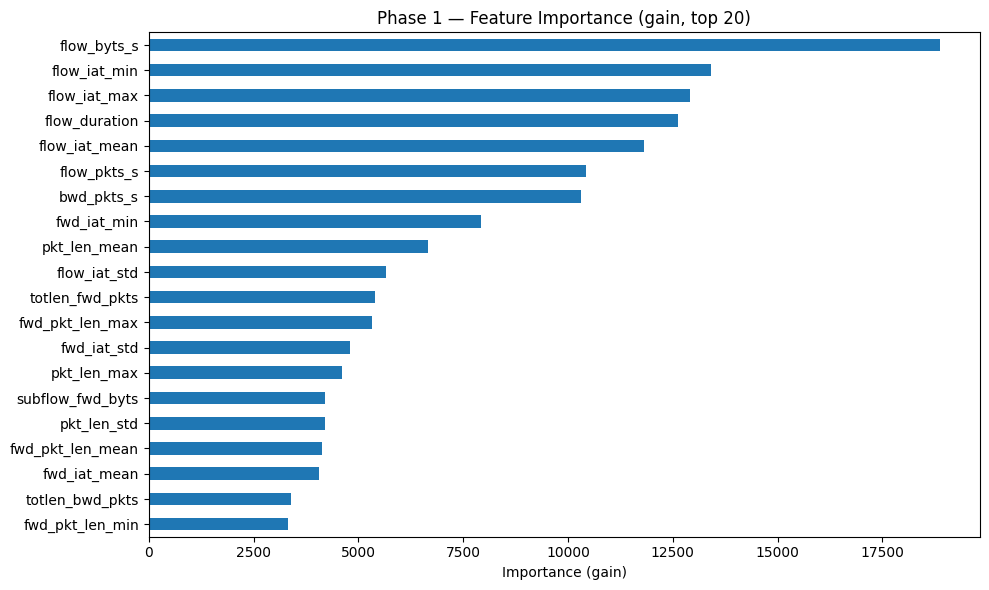

[report] Phase 1 feature importance image saved.


In [27]:
_feat_imp_p1 = pd.Series(
    model.feature_importances_, index=X_train.columns, name="importance"
).nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
_feat_imp_p1.plot(kind="barh", ax=ax)
ax.set_title("Phase 1 — Feature Importance (gain, top 20)")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()

_img_dir = _os.path.join(_os.path.dirname(_report_path), "images")
_os.makedirs(_img_dir, exist_ok=True)
_img_p1_feat_name = f"{_ts}_p1_feature_importance.png"
plt.savefig(_os.path.join(_img_dir, _img_p1_feat_name), dpi=150, bbox_inches="tight")
plt.show()

_report_append(
    f"### Feature Importance\n\n"
    f"![Phase 1 — Feature Importance (top 20)](images/{_img_p1_feat_name})\n\n"
)
print(f"[report] Phase 1 feature importance image saved.")


In [28]:
_p1_report_str = classification_report(y_test, y_pred)
_p1_recall_attack = recall_score(y_test, y_pred, pos_label="attack")
_p1_recall_benign = recall_score(y_test, y_pred, pos_label="benign")
_p1_params_rows = "\n".join(f"| `{k}` | `{v}` |" for k, v in model.get_params().items())

_report_append(
    f"### Final Model — Parameters\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"{_p1_params_rows}\n\n"
    f"### Evaluation (test set — {len(y_test):,} flows)\n\n"
    f"Decision threshold: `{threshold}`\n\n"
    f"```\n{_p1_report_str}```\n\n"
    f"| Class | Recall |\n"
    f"|-------|--------|\n"
    f"| Attack | `{_p1_recall_attack:.4f}` |\n"
    f"| Benign | `{_p1_recall_benign:.4f}` |\n\n"
)
print("[report] Phase 1 evaluation section written.")

[report] Phase 1 evaluation section written.


In [29]:
_model_p1_path = f"../models/binary_classifier_{_ts}.pkl"
dump(model, _model_p1_path)
print(f"Saved → {_model_p1_path}")


Saved → ../models/binary_classifier_20260518_130014.pkl


In [30]:
import re as _re

_ids_path = "../scripts/network_binary_ids.py"
with open(_ids_path) as _f:
    _src = _f.read()

_new_src = _re.sub(
    r"# Minimum probability assigned to the attack class to raise an alert\.\n(?:# .*\n)*THRESHOLD = [\d.]+",
    (
        "# Minimum probability assigned to the attack class to raise an alert.\n"
        "# Optimised by Optuna; auto-updated by notebooks/training.ipynb.\n"
        f"THRESHOLD = {threshold}"
    ),
    _src,
)

_new_src = _re.sub(
    r'MODEL_PATH = os\.path\.join\(os\.path\.dirname\(__file__\), "models", "[^"]+\.pkl"\)',
    f'MODEL_PATH = os.path.join(os.path.dirname(__file__), "models", "binary_classifier_{_ts}.pkl")',
    _new_src,
)

with open(_ids_path, "w") as _f:
    _f.write(_new_src)

print(f"Updated THRESHOLD = {threshold} in {_ids_path}")
print(f"Updated MODEL_PATH → binary_classifier_{_ts}.pkl in {_ids_path}")


Updated THRESHOLD = 0.19976531434163686 in ../scripts/network_binary_ids.py
Updated MODEL_PATH → binary_classifier_20260518_130014.pkl in ../scripts/network_binary_ids.py


In [31]:
_report_append(
    f"### Artifacts\n\n"
    f"| Artifact | Path |\n"
    f"|----------|------|\n"
    f"| Binary classifier | `models/binary_classifier_{_ts}.pkl` |\n"
    f"| Threshold written to script | `scripts/network_binary_ids.py` → `THRESHOLD = {threshold}` |\n\n"
)
print("[report] Phase 1 artifacts section written.")


[report] Phase 1 artifacts section written.


# Data — Phase 2

Fresh balanced collection from the DB, independent of the binary-sampled `df`
used in Phase 1. Each class receives up to `PHASE2_SAMPLES_PER_CLASS` rows so
that no single attack type dominates the multiclass training set.

The same cleaning pipeline as Phase 1 is applied here — but recomputed on this
balanced distribution, because correlation and variance thresholds can differ
when class proportions change.

## Load Data

In [32]:
print("Loading Phase 2 balanced dataset from DB...")
df2 = load_dataset_from_db(
    DB_PATH,
    TABLE,
    samples_per_class=PHASE2_SAMPLES_PER_CLASS,
    benign_label=BENIGN_LABEL,
)
df2.head()

Loading Phase 2 balanced dataset from DB...
Classes: ['benign', 'bruteforce', 'ddos', 'dos', 'malware', 'mitm', 'recon', 'spoofing', 'web']
  benign: 615,317 rows
  bruteforce: 16,397 rows
  ddos: 615,317 rows
  dos: 615,317 rows
  malware: 615,317 rows
  mitm: 90,089 rows
  recon: 615,317 rows
  spoofing: 91,076 rows
  web: 129,356 rows

Total: 3,403,503 rows


,src_ip,dst_ip,src_port,dst_port,protocol,timestamp,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,...,active_max,active_min,active_mean,active_std,idle_max,idle_min,idle_mean,idle_std,cwr_flag_count,label
632380,192.168.1.105,192.168.1.13,1882,1883,6,1.737816e+09,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos
2349899,192.168.137.100,192.168.137.1,38850,53,17,1.673551e+09,0.129643,1720.108783,15.426985,7.713492,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,malware
847624,192.168.137.20,192.168.137.86,43012,554,6,1.666877e+09,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos
1074249,192.168.137.20,192.168.137.223,6267,6668,6,1.666885e+09,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos
2940183,192.168.137.178,192.168.137.20,64340,65129,6,1.664829e+09,0.030025,2797.668112,66.611146,33.305573,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,recon


## Data Cleaning

### Remove useless features

In [33]:
actually_dropped2 = [c for c in USELESS_FEATURES if c in df2.columns]
df2 = df2.drop(columns=actually_dropped2)
df2.columns = df2.columns.str.strip()

print(f"  Shape: {df2.shape}")
print(f"  Dropped: {actually_dropped2}")
df2.head()

  Shape: (3403503, 70)
  Dropped: ['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'init_fwd_win_byts', 'init_bwd_win_byts', 'fwd_byts_b_avg', 'bwd_byts_b_avg', 'fwd_pkts_b_avg', 'bwd_pkts_b_avg', 'fwd_blk_rate_avg', 'bwd_blk_rate_avg']


,protocol,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,...,active_max,active_min,active_mean,active_std,idle_max,idle_min,idle_mean,idle_std,cwr_flag_count,label
632380,6,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,40,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos
2349899,17,0.129643,1720.108783,15.426985,7.713492,7.713492,1,1,61,162,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,malware
847624,6,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,40,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos
1074249,6,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,40,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos
2940183,6,0.030025,2797.668112,66.611146,33.305573,33.305573,1,1,44,40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,recon


### Remove invalid values (NaN / Inf)

In [34]:
df2 = df2.replace([np.inf, -np.inf], np.nan).dropna()

print(f"  Shape: {df2.shape}")
df2.head()

  Shape: (3403503, 70)


,protocol,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,...,active_max,active_min,active_mean,active_std,idle_max,idle_min,idle_mean,idle_std,cwr_flag_count,label
632380,6,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,40,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos
2349899,17,0.129643,1720.108783,15.426985,7.713492,7.713492,1,1,61,162,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,malware
847624,6,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,40,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos
1074249,6,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,40,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos
2940183,6,0.030025,2797.668112,66.611146,33.305573,33.305573,1,1,44,40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,recon


### Remove duplicate rows

In [35]:
_before2 = len(df2)
df2 = df2.drop_duplicates()

print(f"  Removed {_before2 - len(df2):,} duplicates → shape: {df2.shape}")
df2.head()

  Removed 1,817,019 duplicates → shape: (1586484, 70)


,protocol,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,...,active_max,active_min,active_mean,active_std,idle_max,idle_min,idle_mean,idle_std,cwr_flag_count,label
632380,6,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,40,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos
2349899,17,0.129643,1720.108783,15.426985,7.713492,7.713492,1,1,61,162,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,malware
2940183,6,0.030025,2797.668112,66.611146,33.305573,33.305573,1,1,44,40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,recon
2183733,17,1.319881,659.907995,3.030576,1.515288,1.515288,2,2,144,727,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,malware
2452632,17,0.089053,1527.181891,22.458557,11.229279,11.229279,1,1,60,76,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,malware


### Remove highly correlated features

Features with pairwise Pearson correlation > `CORR_THRESHOLD` are dropped.
Recomputed on the balanced distribution of `df2`.

In [36]:
_numeric2 = df2.select_dtypes(include="number").columns.tolist()
_corr2 = df2[_numeric2].corr().abs()
_upper2 = _corr2.where(np.triu(np.ones(_corr2.shape), k=1).astype(bool))
_drop_corr2 = [c for c in _upper2.columns if any(_upper2[c] > CORR_THRESHOLD)]
print(f"  Dropped (corr > {CORR_THRESHOLD}): {_drop_corr2}")

df2 = df2.drop(columns=_drop_corr2)
print(f"  Shape: {df2.shape}")
df2.head()

  Dropped (corr > 0.95): ['fwd_pkts_s', 'fwd_seg_size_min', 'fwd_act_data_pkts', 'fwd_iat_tot', 'fwd_iat_max', 'psh_flag_cnt', 'ack_flag_cnt', 'urg_flag_cnt', 'pkt_size_avg', 'fwd_seg_size_avg', 'bwd_seg_size_avg', 'idle_max']
  Shape: (1586484, 58)


,protocol,flow_duration,flow_byts_s,flow_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,...,subflow_bwd_byts,active_max,active_min,active_mean,active_std,idle_min,idle_mean,idle_std,cwr_flag_count,label
632380,6,0.000000,0.000000,0.000000,0.000000,1,0,40,0,40,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos
2349899,17,0.129643,1720.108783,15.426985,7.713492,1,1,61,162,61,...,162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,malware
2940183,6,0.030025,2797.668112,66.611146,33.305573,1,1,44,40,44,...,40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,recon
2183733,17,1.319881,659.907995,3.030576,1.515288,2,2,144,727,72,...,363,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,malware
2452632,17,0.089053,1527.181891,22.458557,11.229279,1,1,60,76,60,...,76,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,malware


### Remove near-zero variance features

Features whose variance is below `VARIANCE_THRESHOLD` are dropped.

In [37]:
_numeric2 = df2.select_dtypes(include="number").columns.tolist()
_drop_var2 = df2[_numeric2].var().pipe(lambda s: s[s < VARIANCE_THRESHOLD].index.tolist())
print(f"  Dropped (var < {VARIANCE_THRESHOLD}): {_drop_var2}")

df2 = df2.drop(columns=_drop_var2)
print(f"  Shape: {df2.shape}")
df2.head()

  Dropped (var < 0.0001): ['fwd_urg_flags', 'bwd_urg_flags']
  Shape: (1586484, 56)


,protocol,flow_duration,flow_byts_s,flow_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,...,subflow_bwd_byts,active_max,active_min,active_mean,active_std,idle_min,idle_mean,idle_std,cwr_flag_count,label
632380,6,0.000000,0.000000,0.000000,0.000000,1,0,40,0,40,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos
2349899,17,0.129643,1720.108783,15.426985,7.713492,1,1,61,162,61,...,162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,malware
2940183,6,0.030025,2797.668112,66.611146,33.305573,1,1,44,40,44,...,40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,recon
2183733,17,1.319881,659.907995,3.030576,1.515288,2,2,144,727,72,...,363,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,malware
2452632,17,0.089053,1527.181891,22.458557,11.229279,1,1,60,76,60,...,76,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,malware


## Train / Test Split

In [38]:
print(df2["label"].value_counts().to_string())

y2 = df2["label"]
X2 = df2.drop(columns=df2.select_dtypes(exclude="number").columns)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_SEED, stratify=y2
)
print(f"\nTrain: {X2_train.shape}, Test: {X2_test.shape}")
print(f"Classes: {sorted(y2.unique())}")

label
benign        416568
malware       406563
recon         240114
dos           206428
ddos          115649
mitm           69113
spoofing       61444
web            59650
bruteforce     10955

Train: (1269187, 55), Test: (317297, 55)
Classes: ['benign', 'bruteforce', 'ddos', 'dos', 'malware', 'mitm', 'recon', 'spoofing', 'web']


In [39]:
_p2_class_counts = df2["label"].value_counts().sort_index()
_p2_counts_rows = "\n".join(f"| `{c}` | {n:,} |" for c, n in _p2_class_counts.items())
_report_append(
    f"## Dataset — Phase 2\n\n"
    f"Balanced query: up to `{PHASE2_SAMPLES_PER_CLASS:,}` rows per class from the DB.\n\n"
    f"Raw shape after load and cleaning: `{df2.shape}`\n\n"
    f"| Class | Rows |\n"
    f"|-------|------|\n"
    f"{_p2_counts_rows}\n"
    f"| **Total** | **{len(df2):,}** |\n\n"
    f"Train / test split: `{len(X2_train):,}` / `{len(X2_test):,}` (80/20, stratified)\n\n"
)
print("[report] Dataset — Phase 2 section written.")

[report] Dataset — Phase 2 section written.


# Phase 2 — Multiclass Classification

Flows flagged as attacks by Phase 1 are categorised into all known attack types.
The model is trained on every attack class without relabelling.

Flows whose maximum predicted probability falls below
`PHASE2_CONFIDENCE_THRESHOLD` are considered ambiguous and forwarded to
Phase 3 for unsupervised clustering.

## Hyperparameter Optimisation

In [40]:
N_CLASSES = y2_train.nunique()

FIXED_PARAMS_P2 = {
    "objective": "multiclass",
    "num_class": N_CLASSES,
    "metric": "multi_logloss",
    "boosting_type": "gbdt",
    "class_weight": "balanced",
    "random_state": RANDOM_SEED,
    "verbosity": -1,
    "force_row_wise": True,
    "n_jobs": 8,
}


def objective_p2(trial: optuna.Trial) -> float:
    """
    Optuna objective for Phase 2 multiclass classification.

    Optimises macro-averaged F1-score across all attack classes.
    """
    params = {**FIXED_PARAMS_P2, **_suggest_lgb_params(trial)}

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    for train_idx, val_idx in cv.split(X2_train, y2_train):
        X_tr, X_val = X2_train.iloc[train_idx], X2_train.iloc[val_idx]
        y_tr, y_val = y2_train.iloc[train_idx], y2_train.iloc[val_idx]

        clf = lgb.LGBMClassifier(**params)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val)

        scores.append(f1_score(y_val, y_pred, average="macro", zero_division=0))

    return np.mean(scores)

In [41]:
study_p2 = optuna.create_study(direction="maximize")
study_p2.optimize(objective_p2, n_trials=20, timeout=1800, show_progress_bar=True)

Best trial: 2. Best value: 0.699474:  40%|████      | 8/20 [33:25<50:07, 250.64s/it, 2005.14/1800 seconds]  


In [42]:
print("Best macro F1:", study_p2.best_value)
print("Best params:", study_p2.best_params)

Best macro F1: 0.6994741098275159
Best params: {'num_leaves': 66, 'max_depth': -1, 'min_child_samples': 26, 'min_split_gain': 0.9741767619681504, 'learning_rate': 0.04502062038376461, 'n_estimators': 511, 'subsample': 0.8466439478750473, 'subsample_freq': 4, 'colsample_bytree': 0.6732578885909489, 'reg_alpha': 0.011483838528657274, 'reg_lambda': 0.06073279347562471, 'max_bin': 377}


In [43]:
_p2_param_rows = "\n".join(f"| `{k}` | `{v}` |" for k, v in study_p2.best_params.items())
_report_append(
    f"---\n\n"
    f"## Phase 2 — Multi-class Classifier\n\n"
    f"**Algorithm:** LightGBM (`LGBMClassifier`, multiclass)\n\n"
    f"**Fixed params:** `{FIXED_PARAMS_P2}`\n\n"
    f"### Configuration\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"| Samples per class (cap) | `{PHASE2_SAMPLES_PER_CLASS:,}` |\n"
    f"| Confidence threshold (→ Phase 3) | `{PHASE2_CONFIDENCE_THRESHOLD}` |\n"
    f"| Train size | `{len(X2_train):,}` |\n"
    f"| Test size | `{len(X2_test):,}` |\n\n"
    f"### Hyperparameter Optimization (Optuna)\n\n"
    f"| Setting | Value |\n"
    f"|---------|-------|\n"
    f"| Trials | 20 |\n"
    f"| Timeout | 1800 s |\n"
    f"| CV folds | 3 (StratifiedKFold) |\n"
    f"| Objective | Macro F1 |\n"
    f"| Best macro F1 | `{study_p2.best_value:.6f}` |\n"
    f"| Best trial | #{study_p2.best_trial.number} |\n\n"
    f"#### Best parameters\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"{_p2_param_rows}\n\n"
)
print("[report] Phase 2 Optuna section written.")

[report] Phase 2 Optuna section written.


## Final Model

In [44]:
best_p2 = study_p2.best_params.copy()
model_p2 = lgb.LGBMClassifier(**best_p2, **FIXED_PARAMS_P2)
model_p2.fit(X2_train, y2_train)

,boosting_type,'gbdt'
,num_leaves,66
,max_depth,-1
,learning_rate,0.04502062038376461
,n_estimators,511
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.9741767619681504
,min_child_weight,0.001
,min_child_samples,26


In [45]:
y2_pred = model_p2.predict(X2_test)
print(classification_report(y2_test, y2_pred))

              precision    recall  f1-score   support

      benign       0.83      0.69      0.76     83314
  bruteforce       0.20      0.77      0.32      2191
        ddos       0.98      0.95      0.97     23130
         dos       0.98      0.95      0.96     41285
     malware       0.90      0.78      0.83     81313
        mitm       0.41      0.71      0.52     13822
       recon       0.84      0.67      0.75     48023
    spoofing       0.28      0.73      0.41     12289
         web       0.76      0.83      0.80     11930

    accuracy                           0.77    317297
   macro avg       0.69      0.79      0.70    317297
weighted avg       0.83      0.77      0.79    317297



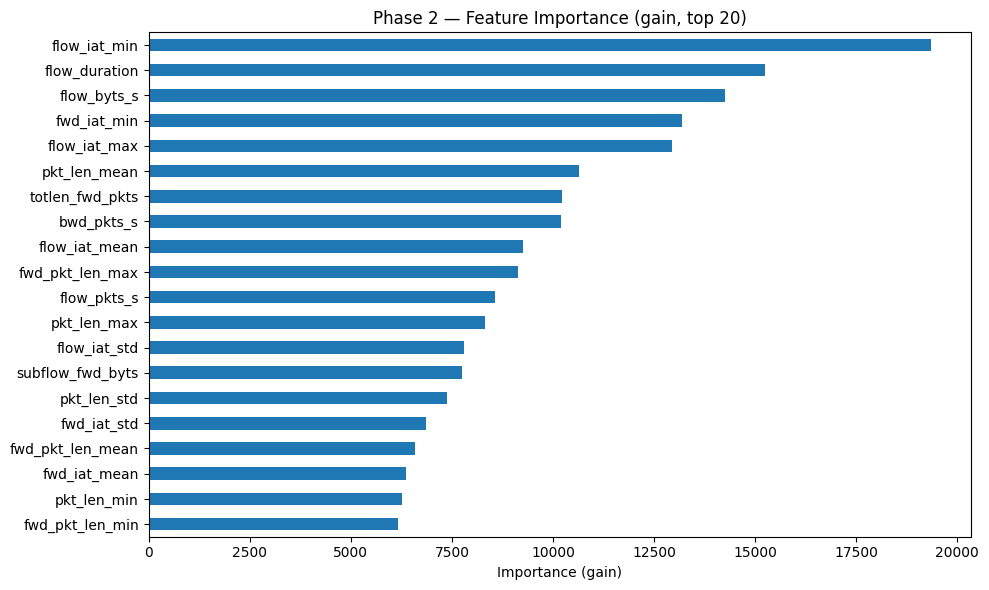

[report] Phase 2 feature importance image saved.


In [46]:
_feat_imp_p2 = pd.Series(
    model_p2.feature_importances_, index=X2_train.columns, name="importance"
).nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
_feat_imp_p2.plot(kind="barh", ax=ax)
ax.set_title("Phase 2 — Feature Importance (gain, top 20)")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()

_img_p2_feat_name = f"{_ts}_p2_feature_importance.png"
plt.savefig(_os.path.join(_img_dir, _img_p2_feat_name), dpi=150, bbox_inches="tight")
plt.show()

_report_append(
    f"### Feature Importance\n\n"
    f"![Phase 2 — Feature Importance (top 20)](images/{_img_p2_feat_name})\n\n"
)
print(f"[report] Phase 2 feature importance image saved.")


In [47]:
probs_p2 = model_p2.predict_proba(X2_test)
max_conf = probs_p2.max(axis=1)

known_mask = max_conf >= PHASE2_CONFIDENCE_THRESHOLD
print(f"Flows classified by Phase 2: {known_mask.sum():,} ({known_mask.mean():.1%})")
print(f"Flows forwarded to Phase 3:  {(~known_mask).sum():,} ({(~known_mask).mean():.1%})")

Flows classified by Phase 2: 221,086 (69.7%)
Flows forwarded to Phase 3:  96,211 (30.3%)


In [48]:
_p2_report_str = classification_report(y2_test, y2_pred)
_p2_params_rows = "\n".join(f"| `{k}` | `{v}` |" for k, v in model_p2.get_params().items())
_report_append(
    f"### Final Model — Parameters\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"{_p2_params_rows}\n\n"
    f"### Evaluation (test set — {len(y2_test):,} flows)\n\n"
    f"```\n{_p2_report_str}```\n\n"
    f"### Confidence routing\n\n"
    f"| Routing | Flows | Share |\n"
    f"|---------|-------|-------|\n"
    f"| Classified by Phase 2 (confidence ≥ {PHASE2_CONFIDENCE_THRESHOLD}) | {known_mask.sum():,} | {known_mask.mean():.1%} |\n"
    f"| Forwarded to Phase 3 (confidence < {PHASE2_CONFIDENCE_THRESHOLD}) | {(~known_mask).sum():,} | {(~known_mask).mean():.1%} |\n\n"
)
print("[report] Phase 2 evaluation + routing section written.")

[report] Phase 2 evaluation + routing section written.


In [49]:
_model_p2_path = f"../models/multiclass_classifier_{_ts}.pkl"
dump(model_p2, _model_p2_path)
print(f"Saved → {_model_p2_path}")


Saved → ../models/multiclass_classifier_20260518_130014.pkl


In [50]:
_report_append(
    f"### Artifacts\n\n"
    f"| Artifact | Path |\n"
    f"|----------|------|\n"
    f"| Multi-class classifier | `models/multiclass_classifier_{_ts}.pkl` |\n\n"
)
print("[report] Phase 2 artifacts section written.")


[report] Phase 2 artifacts section written.


# Phase 3 — Unsupervised Clustering

Flows that Phase 2 could not classify with sufficient confidence are
analysed here to discover **novel attack patterns** (potential zero-day
threats). The pipeline uses two steps:

1. **UMAP** — reduces the high-dimensional feature space to a compact
   embedding that preserves local and global structure.
2. **HDBSCAN** — density-based clustering that automatically determines
   the number of clusters and labels outliers as noise (-1).

Each discovered cluster represents a group of flows with similar network
behaviour — a candidate for a new attack category.

## Data

In [51]:
# Low-confidence flows from Phase 2 (using the test split as a proxy).
# In production these would be streamed from Phase 2's inference output.
low_conf_mask = probs_p2.max(axis=1) < PHASE2_CONFIDENCE_THRESHOLD
X3 = X2_test[low_conf_mask]

print(f"Low-confidence flows: {len(X3):,} ({low_conf_mask.mean():.1%} of Phase 2 test set)")
print(f"Feature shape: {X3.shape}")

Low-confidence flows: 96,211 (30.3% of Phase 2 test set)
Feature shape: (96211, 55)


## UMAP Dimensionality Reduction

In [52]:
reducer = umap.UMAP(
    n_components=P3_UMAP_N_COMPONENTS,
    n_neighbors=P3_UMAP_N_NEIGHBORS,
    min_dist=P3_UMAP_MIN_DIST,
    random_state=RANDOM_SEED,
)
X3_embedded = reducer.fit_transform(X3.values)

print(f"UMAP: {X3.shape} → {X3_embedded.shape}")

/home/linkezio/Projects/A Hierarchical MEC and IoT Solution for Cyber-Attack Detection in 6G Networks/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: (96211, 55) → (96211, 10)


In [53]:
_report_append(
    f"---\n\n"
    f"## Phase 3 — Clustering (UMAP + HDBSCAN)\n\n"
    f"Input: **{len(X3):,} flows** with low Phase 2 confidence (< {PHASE2_CONFIDENCE_THRESHOLD})\n\n"
    f"### UMAP — Dimensionality Reduction\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"| n_components | `{P3_UMAP_N_COMPONENTS}` |\n"
    f"| n_neighbors | `{P3_UMAP_N_NEIGHBORS}` |\n"
    f"| min_dist | `{P3_UMAP_MIN_DIST}` |\n"
    f"| random_state | `{RANDOM_SEED}` |\n"
    f"| Input shape | `{X3.shape}` |\n"
    f"| Output shape | `{X3_embedded.shape}` |\n\n"
)
print("[report] Phase 3 UMAP section written.")

[report] Phase 3 UMAP section written.


## HDBSCAN Clustering

In [54]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=P3_HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=P3_HDBSCAN_MIN_SAMPLES,
    prediction_data=True,
)
cluster_labels = clusterer.fit_predict(X3_embedded)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = (cluster_labels == -1).sum()

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise:,} ({n_noise / len(cluster_labels):.1%})")

Clusters found : 222
Noise points   : 14,577 (15.2%)


In [55]:
_report_append(
    f"### HDBSCAN — Density Clustering\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"| min_cluster_size | `{P3_HDBSCAN_MIN_CLUSTER_SIZE}` |\n"
    f"| min_samples | `{P3_HDBSCAN_MIN_SAMPLES}` |\n"
    f"| prediction_data | `True` |\n\n"
    f"| Result | Value |\n"
    f"|--------|-------|\n"
    f"| Clusters found | `{n_clusters}` |\n"
    f"| Noise points | `{n_noise:,}` (`{n_noise / len(cluster_labels):.1%}` of inputs) |\n\n"
)
print("[report] Phase 3 HDBSCAN section written.")

[report] Phase 3 HDBSCAN section written.


## Cluster Analysis

In [56]:
cluster_series = pd.Series(cluster_labels, index=X3.index, name="cluster")
counts = cluster_series.value_counts().sort_index()

print("Cluster  | Size")
print("-" * 22)
for label, count in counts.items():
    tag = "(noise)" if label == -1 else ""
    print(f"  {label:>5}  | {count:>7,}  {tag}")

Cluster  | Size
----------------------
     -1  |  14,577  (noise)
      0  |     494  
      1  |     188  
      2  |     202  
      3  |     264  
      4  |     358  
      5  |     177  
      6  |   1,292  
      7  |     125  
      8  |   1,752  
      9  |     167  
     10  |     157  
     11  |     265  
     12  |     147  
     13  |     906  
     14  |     510  
     15  |     374  
     16  |     193  
     17  |     125  
     18  |     117  
     19  |     295  
     20  |     235  
     21  |     278  
     22  |     202  
     23  |     166  
     24  |     340  
     25  |     227  
     26  |     157  
     27  |     142  
     28  |   3,255  
     29  |   1,123  
     30  |   1,169  
     31  |     150  
     32  |     206  
     33  |     319  
     34  |     143  
     35  |     447  
     36  |     186  
     37  |     685  
     38  |     121  
     39  |     166  
     40  |     266  
     41  |     194  
     42  |     208  
     43  |     341  
     44  

In [57]:
_cluster_rows = "\n".join(
    f"| {'noise (-1)' if lbl == -1 else lbl} | {cnt:,} |"
    for lbl, cnt in counts.items()
)
_report_append(
    f"### Cluster Distribution\n\n"
    f"| Cluster | Flows |\n"
    f"|---------|-------|\n"
    f"{_cluster_rows}\n\n"
)
print("[report] Phase 3 cluster distribution written.")

[report] Phase 3 cluster distribution written.


## Visualisation

A 2-D UMAP embedding is computed separately for visualisation only —
the clustering above uses the higher-dimensional (`P3_UMAP_N_COMPONENTS`)
embedding for better density estimation.

/home/linkezio/Projects/A Hierarchical MEC and IoT Solution for Cyber-Attack Detection in 6G Networks/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_207995/707128838.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_labels))
/tmp/ipykernel_207995/707128838.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


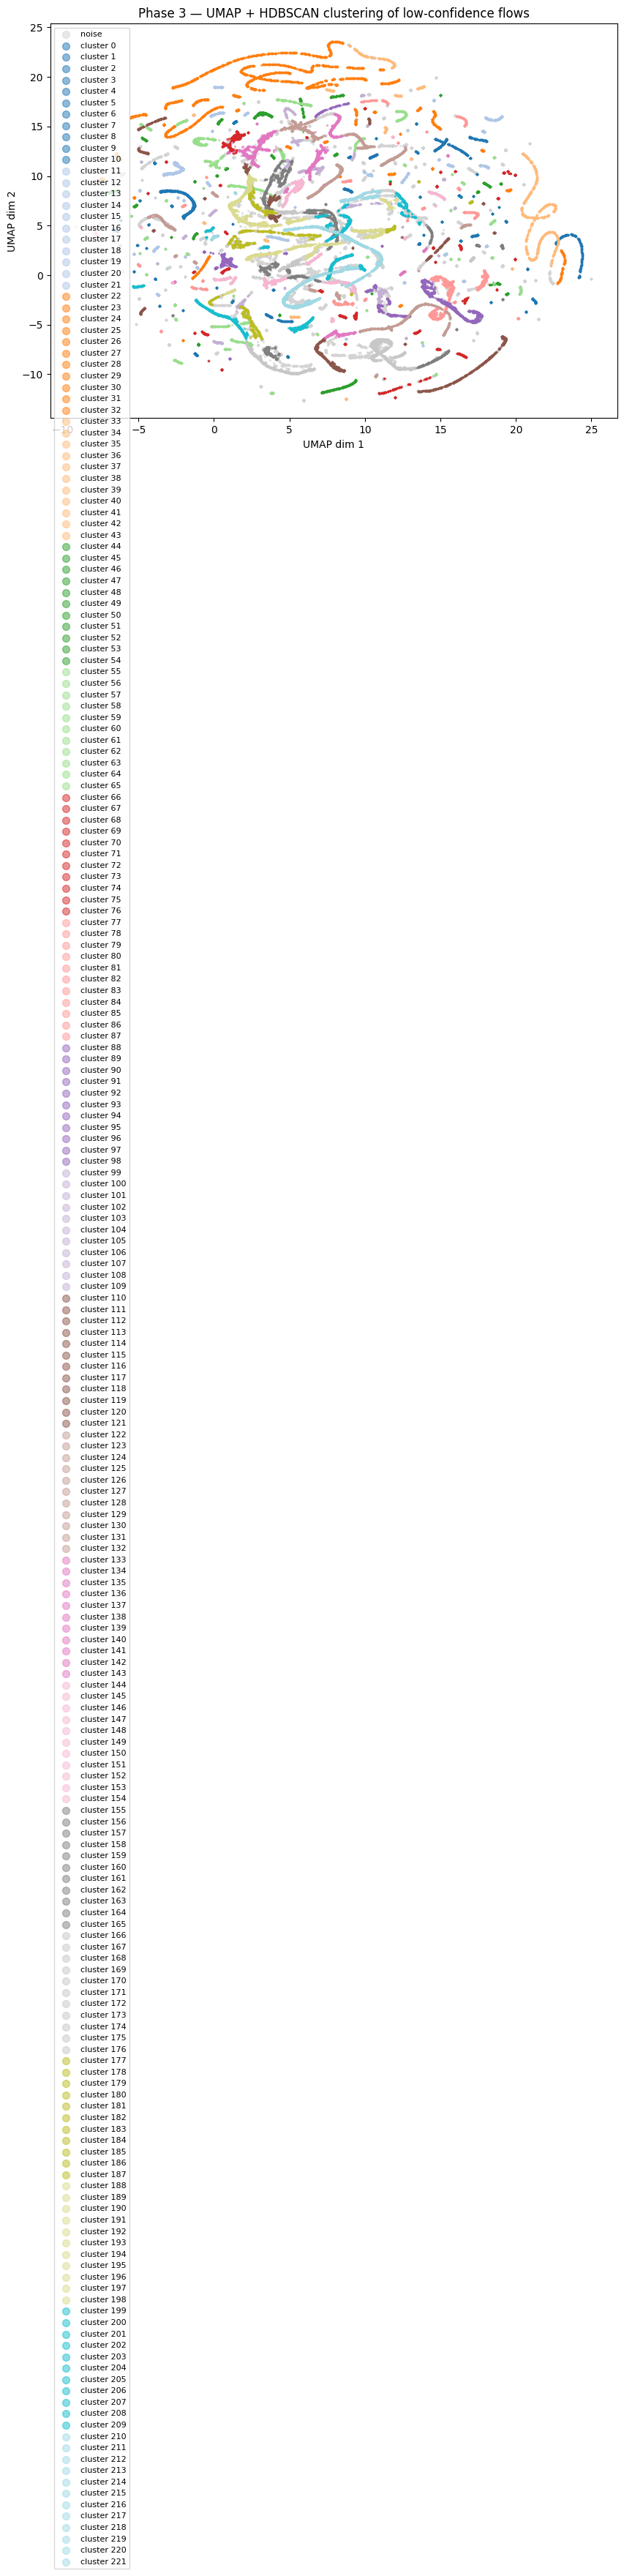

[report] Phase 3 UMAP cluster image saved.


In [58]:
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=P3_UMAP_N_NEIGHBORS,
    min_dist=P3_UMAP_MIN_DIST,
    random_state=RANDOM_SEED,
)
X3_2d = reducer_2d.fit_transform(X3.values)

fig, ax = plt.subplots(figsize=(10, 7))
unique_labels = sorted(set(cluster_labels))
cmap = plt.cm.get_cmap("tab20", len(unique_labels))

for i, label in enumerate(unique_labels):
    mask = cluster_labels == label
    color = "lightgrey" if label == -1 else cmap(i)
    tag   = "noise" if label == -1 else f"cluster {label}"
    ax.scatter(X3_2d[mask, 0], X3_2d[mask, 1],
               c=[color], s=2, alpha=0.5, label=tag)

ax.set_title("Phase 3 — UMAP + HDBSCAN clustering of low-confidence flows")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.legend(markerscale=5, loc="best", fontsize=8)
plt.tight_layout()

_img_p3_umap_name = f"{_ts}_p3_umap_clusters.png"
plt.savefig(_os.path.join(_img_dir, _img_p3_umap_name), dpi=150, bbox_inches="tight")
plt.show()

_report_append(
    f"### UMAP Cluster Visualisation\n\n"
    f"![Phase 3 — UMAP + HDBSCAN clustering](images/{_img_p3_umap_name})\n\n"
)
print(f"[report] Phase 3 UMAP cluster image saved.")

In [59]:
_model_umap_path     = f"../models/umap_reducer_{_ts}.pkl"
_model_hdbscan_path  = f"../models/hdbscan_clusterer_{_ts}.pkl"
dump(reducer,   _model_umap_path)
dump(clusterer, _model_hdbscan_path)
print(f"Saved → {_model_umap_path}")
print(f"Saved → {_model_hdbscan_path}")


Saved → ../models/umap_reducer_20260518_130014.pkl
Saved → ../models/hdbscan_clusterer_20260518_130014.pkl


In [60]:
_elapsed = _dt.now() - _report_start
_report_append(
    f"### Artifacts\n\n"
    f"| Artifact | Path |\n"
    f"|----------|------|\n"
    f"| UMAP reducer | `models/umap_reducer_{_ts}.pkl` |\n"
    f"| HDBSCAN clusterer | `models/hdbscan_clusterer_{_ts}.pkl` |\n\n"
    f"---\n\n"
    f"## Summary\n\n"
    f"| | |\n"
    f"|---|---|\n"
    f"| **Total training time** | `{str(_elapsed).split('.')[0]}` |\n"
    f"| **Phase 1 model** | `models/binary_classifier_{_ts}.pkl` |\n"
    f"| **Phase 1 threshold** | `{threshold}` → written to `scripts/network_binary_ids.py` |\n"
    f"| **Phase 2 model** | `models/multiclass_classifier_{_ts}.pkl` |\n"
    f"| **Phase 3 UMAP** | `models/umap_reducer_{_ts}.pkl` |\n"
    f"| **Phase 3 HDBSCAN** | `models/hdbscan_clusterer_{_ts}.pkl` |\n"
    f"| **Phase 1 best F2-score** | `{study.best_value:.4f}` |\n"
    f"| **Phase 2 best macro F1** | `{study_p2.best_value:.4f}` |\n"
    f"| **Phase 2 → Phase 3 routing** | `{(~known_mask).mean():.1%}` of flows |\n"
    f"| **Phase 3 clusters** | `{n_clusters}` |\n\n"
    f"*Generated by `notebooks/training.ipynb`*\n"
)
print(f"[report] Complete → {_report_path}")


[report] Complete → ../docs/results/training_20260518_130014.md
